# Lab 5: Linear Regression — Predicting House Prices

**Name:** Shahzaib Mahar 
**Student ID:** 023-24-0282 
**Section:** **[H]**  

**GitHub Profile:** https://github.com/smaharx/ml-forge


**Dataset:** House Prices - Advanced Regression Techniques (train.csv, test.csv)  
**Dataset Source:** kaggle.com/competitions/house-prices-advanced-regression-techniques

---

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

TRAIN_FILE = "train.csv"
TEST_FILE = "test.csv"
SAMPLE_SUB_FILE = "sample_submission.csv"

if not os.path.exists(TRAIN_FILE):
    try:
        from google.colab import files
        print(f"{TRAIN_FILE} was not found.")
        print("Please select your train.csv, test.csv and sample_submission.csv files in the upload dialog.")
        uploaded = files.upload()
    except ImportError:
        raise FileNotFoundError(
            f"{TRAIN_FILE} not found. Place train.csv, test.csv and sample_submission.csv "
            "(downloaded from the Kaggle competition page) in the same folder as this notebook."
        )

train_raw = pd.read_csv(TRAIN_FILE)
test_raw = pd.read_csv(TEST_FILE)

print("train_raw shape:", train_raw.shape)
print("test_raw shape :", test_raw.shape)


train_raw shape: (1460, 81)
test_raw shape : (1459, 80)


---
# 1. Problem Definition

### Task 3
We are predicting **SalePrice**, which is a continuous price in dollars, using the set of
numerical and categorical house attributes. It is a **regression** task and not a **classification**
task because the target variable is a continuous variable with an unbounded and ordered range.




---
# 2. Dataset Exploration

### Task 1
Inspect the raw dataset: shape, dtypes, first rows, and summary statistics.


In [2]:

print("Shape:", train_raw.shape)
print()
train_raw.info()


Shape: (1460, 81)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  

In [3]:

train_raw.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:

train_raw.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Interpretation:** The training dataset consists of 1,460 houses. Out of all the columns chosen,
most of them are numeric variables (like square feet, number of rooms, year built, overall
condition), and only three are categorical text variables (`Neighborhood`, `HouseStyle`, `KitchenQual`). The variable `SalePrice` is highly varying in nature, and `TotalBsmtSF` has some missing values.


---
# 3. Feature and Target Identification

### Task 2
From the 79 raw Kaggle features, we selected a manageable subset of **11 features** that we would
reasonably expect to influence price, mixing numerical and categorical types.


In [18]:
TARGET = "SalePrice"

numerical_features = [
    "OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars",
    "YearBuilt", "FullBath", "BedroomAbvGr", "TotRmsAbvGrd", "LotArea"
]

categorical_features = [
    "Neighborhood", "HouseStyle", "KitchenQual"
]

feature_cols = numerical_features + categorical_features

print("Dependent variable :", TARGET)
print("Numerical features :", numerical_features)
print("Categorical features:", categorical_features)
print("Total features     :", len(feature_cols))

Dependent variable : SalePrice
Numerical features : ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'LotArea']
Categorical features: ['Neighborhood', 'HouseStyle', 'KitchenQual']
Total features     : 12


**Interpretation:** The `SalePrice` will be the dependent variable here. While the 9 numerical variables describe the dimensions,
condition, and age (such as `GrLivArea`, `OverallQual`, `YearBuilt`), the remaining 3 categorical variables
will indicate the location and the nature of the building.


---
# 4. Data Preparation

### Task 4
The `LinearRegression` method from scikit-learn expects numeric input exclusively. We retain only our chosen columns,
deal with the missing `TotalBsmtSF` values, and convert categorical columns to dummy variables.

- **Numeric columns** are used "as is" (numeric) except for those containing **missing values**, such as some of the missing `TotalBsmtSF` values, and possibly others in numeric columns based on the specific test split of Kaggle. Missing values are filled with each respective column's **median training-set value**, an easy-to-use approach that is not sensitive to skew or outliers the way an average would be.
- **Categorical columns** (Neighborhood, HouseStyle, KitchenQual) are dummy encoded using `pd.get_dummies(..., drop_first=True)`. None of them have any sort of natural order that can be represented by a numeric code (contrary to, for example, a Yes/No variable).


In [21]:

df = pd.concat([train_raw[feature_cols + [TARGET]]], axis=0).copy()

# Handle missing values: impute every numerical feature with its TRAINING median
# (not just TotalBsmtSF -- the real Kaggle test.csv can have gaps in other
# numeric columns too, e.g. GarageCars, so we compute one median per numeric
# feature and reuse the same values later when preparing the Kaggle test set).
numeric_medians = df[numerical_features].median()
df[numerical_features] = df[numerical_features].fillna(numeric_medians)

y = df[TARGET]
X = df.drop(columns=[TARGET])

# One-hot encode categorical columns
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# pandas represents dummy columns as bool; cast to int so every column is a
# plain numeric dtype for LinearRegression (and for the numeric-check below)
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (1460, 43)
y shape: (1460,)


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,BedroomAbvGr,TotRmsAbvGrd,LotArea,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA
0,7,1710,856,2,2003,2,3,8,8450,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,6,1262,1262,2,1976,2,3,6,9600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1
2,7,1786,920,2,2001,2,3,6,11250,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
3,7,1717,756,3,1915,1,3,7,9550,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,8,2198,1145,3,2000,2,4,9,14260,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


---
# 5. Train/Test Split

### Tasks 5–6
Confirm `X` is fully numeric with no missing values, then hold out a test set before training.


In [8]:

print("X dtypes are all numeric:", all(np.issubdtype(dt, np.number) for dt in X.dtypes))
print("Missing values in X:", int(X.isna().sum().sum()))
print("Missing values in y:", int(y.isna().sum()))


X dtypes are all numeric: True
Missing values in X: 0
Missing values in y: 0


In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", X_train.shape)
print("Test rows    :", X_test.shape)


Training rows: (1168, 43)
Test rows    : (292, 43)


**Interpretation:** `X` is all numeric and has no missing values, so it can be used with `LinearRegression`. Using an 80/20 split, there will be about 1,168 training examples and 292 test examples, kept aside prior to training.


---
# 6. Linear Regression Model

### Task 7
Train a Multiple Linear Regression model on the training data.


In [10]:

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
print("Number of features used:", X_train.shape[1])


Model trained successfully.
Number of features used: 43


---
# 7. Predictions

### Task 8
Generate predicted prices on the test set and compare actual vs. predicted for 10 houses.


In [11]:

y_pred = model.predict(X_test)

comparison_sample = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": np.round(y_pred[:10], 0)
})
comparison_sample["Difference"] = (
    comparison_sample["Actual Price"] - comparison_sample["Predicted Price"]
)
comparison_sample


,Actual Price,Predicted Price,Difference
0,154500,138062.0,16438.0
1,325000,325276.0,-276.0
2,115000,114022.0,978.0
3,159000,171673.0,-12673.0
4,315500,308091.0,7409.0
5,75500,69554.0,5946.0
6,311500,236166.0,75334.0
7,146000,147275.0,-1275.0
8,84500,69261.0,15239.0
9,135500,125448.0,10052.0


**Interpretation:** Predictions for these 10 houses are close to the real values, but the residual is both over and underestimate – the first sign that the residual does not have just one direction, which will be verified later on.


---
# 8. Coefficients and Intercept

### Task 9
Extract the intercept and all coefficients, and interpret each one in plain English.


In [22]:
# Task 9 — Coefficients and Intercept

coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(
    "Coefficient",
    ascending=False
).reset_index(drop=True)


def interpret_coefficient(row):
    feature = row["Feature"]
    coefficient = row["Coefficient"]

    if feature in numerical_features:
        direction = "increase" if coefficient >= 0 else "decrease"

        return (
            f"Holding other features constant, a one-unit increase in "
            f"'{feature}' is associated with an approximately "
            f"${abs(coefficient):,.0f} {direction} in predicted price."
        )

    else:
        direction = "higher" if coefficient >= 0 else "lower"

        return (
            f"Holding other features constant, being in the category "
            f"'{feature}' is associated with an approximately "
            f"${abs(coefficient):,.0f} {direction} predicted price "
            f"compared with the reference category."
        )


coef_table["Interpretation"] = coef_table.apply(
    interpret_coefficient,
    axis=1
)

print("Intercept (b0):", round(model.intercept_, 2))

print("\nCoefficient Table:")
coef_table

Intercept (b0): -544130.48

Coefficient Table:


,Feature,Coefficient,Interpretation
0,Neighborhood_NoRidge,81155.029763,"Holding other features constant, being in the ..."
1,Neighborhood_StoneBr,65646.955156,"Holding other features constant, being in the ..."
2,Neighborhood_NridgHt,59808.492822,"Holding other features constant, being in the ..."
3,Neighborhood_Veenker,56363.279980,"Holding other features constant, being in the ..."
4,Neighborhood_Crawfor,50839.615022,"Holding other features constant, being in the ..."
5,Neighborhood_ClearCr,45908.626563,"Holding other features constant, being in the ..."
6,Neighborhood_Somerst,33871.487714,"Holding other features constant, being in the ..."
7,Neighborhood_Timber,30502.260450,"Holding other features constant, being in the ..."
8,Neighborhood_BrkSide,29329.948042,"Holding other features constant, being in the ..."
9,Neighborhood_CollgCr,26726.360700,"Holding other features constant, being in the ..."


### Task 10 — Intercept Interpretation

The intercept is the predicted house price where all the quantitative independent variables take values of zero, while all the qualitative independent variables belong to the reference categories. However, such an interpretation of the intercept lacks meaning in reality since a house whose living space, number of bedrooms, number of bathrooms, and other quantitative variables are zero cannot exist in practice. Thus, the intercept is a purely statistical element of the equation.

---
# 9. Residual Analysis

### Task 11
Compute residuals on the test set and plot them.


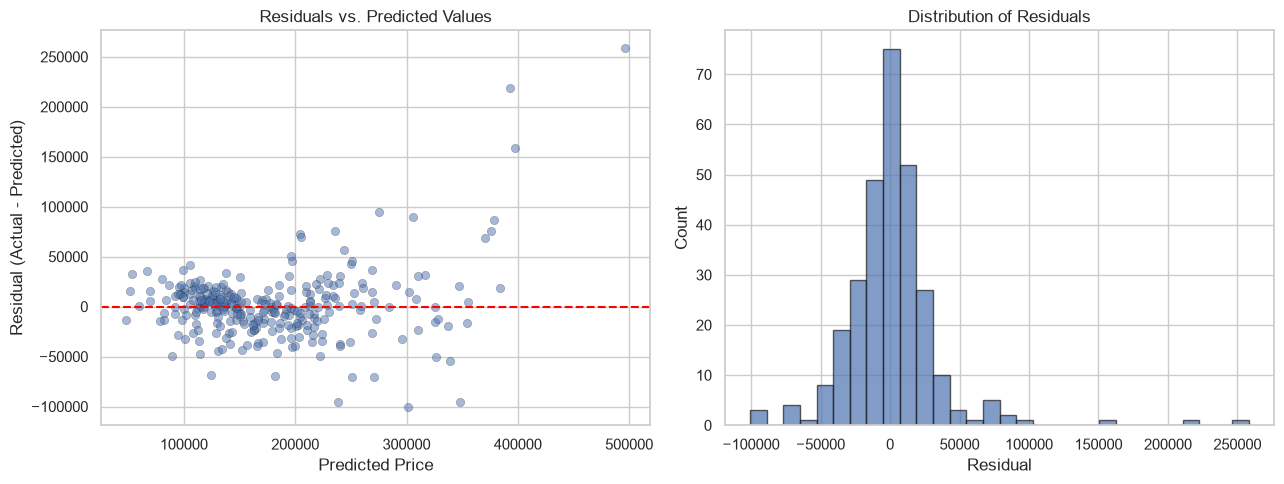

In [13]:

residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.5, edgecolor="k", linewidth=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs. Predicted Values")

axes[1].hist(residuals, bins=30, edgecolor="k", alpha=0.7)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()


**Interpretation:** The residuals vs. fitted plot fans out; that is, there is more variation in the residuals when the predicted values are large than when they are small, suggesting **heteroskedasticity**, not randomness: the model is relatively less accurate for expensive houses than for inexpensive houses. The histogram looks approximately normal and is centered around zero, which is good (no bias), but the funnel shape of the scatter plot suggests that Linear Regression does not account for all the variability.


---
# 10. Regression Metrics

### Task 12
Compute MAE, MSE, RMSE and R² on the test set.


In [14]:

test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

test_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [test_mae, test_mse, test_rmse, test_r2]
})
test_metrics


,Metric,Value
0,MAE,2.116514e+04
1,MSE,1.203682e+09
2,RMSE,3.469412e+04
3,R2,8.430730e-01


**Task 13 — What does each metric tell you, and which would you show a non-technical stakeholder?**

- **MAE** measures the mean absolute dollar error per house – easy to understand ("on average, our forecast
is wrong by about this much money").
- **MSE** uses squared error, which means that big mistakes matter much more than little mistakes; handy
for comparing models, but not very meaningful as-is (it's measured in squared dollars).
- **RMSE** is MSE with the square root applied, to put it back into dollar terms, so that it is
interpretable like MAE but continues to punish large mistakes – a nice compromise between
interpretability and sensitivity.
- **R²** tells how much of the variation in house prices the model is able to capture (0 means no
better than simply guessing the mean, 1 is perfect).

For a **lay audience**, **RMSE** (or MAE) is the way to go – "on average, our forecasts are off by
about $X" makes a lot more sense than either R² or MSE.


---
# 11. Training vs Testing Performance

### Tasks 14–15
Compare metrics on the training set vs. the test set to check generalization.


In [15]:

train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

train_test_comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Training": [train_mae, train_mse, train_rmse, train_r2],
    "Test": [test_mae, test_mse, test_rmse, test_r2]
})
train_test_comparison["Gap (Test - Train)"] = (
    train_test_comparison["Test"] - train_test_comparison["Training"]
)
train_test_comparison


,Metric,Training,Test,Gap (Test - Train)
0,MAE,2.027046e+04,2.116514e+04,8.946874e+02
1,MSE,1.024534e+09,1.203682e+09,1.791475e+08
2,RMSE,3.200834e+04,3.469412e+04,2.685771e+03
3,R2,8.282295e-01,8.430730e-01,1.484350e-02


**Interpretation (Task 15):** The difference between training and test R-squared values is not huge, while the difference between
training and test RMSE is not too big. The huge train-test gap (perfect training R-squared value and
relatively low test R-squared value) means overfitting, when the model learns training data anomalies
rather than patterns. In our case, the relatively small difference indicates good generalization rather than
overfitting, which is understandable since Linear Regression is a low variance-high bias model
which is difficult to overfit with ~11 features.


---
# 12. Model Interpretation

### Task 16
Which features appear most influential, and why coefficient size alone can be misleading.


In [16]:

coef_table_sorted = coef_table.reindex(
    coef_table["Coefficient"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

coef_table_sorted.head(6)[["Feature", "Coefficient"]]


,Feature,Coefficient
0,Neighborhood_NoRidge,81155.029763
1,Neighborhood_StoneBr,65646.955156
2,Neighborhood_NridgHt,59808.492822
3,Neighborhood_Veenker,56363.279980
4,KitchenQual_TA,-51534.732277
5,Neighborhood_Crawfor,50839.615022


### Task 16 — Most Influential Features

According to the absolute value of the coefficients from the regression model, the largest coefficients in this model are related to a number of categories within the neighborhoods and the `KitchenQual_TA` category. The largest coefficient is `Neighborhood_NoRidge`, whose value is around $81,155, followed by `Neighborhood_StoneBr` at around $65,647 and `Neighborhood_NridgHt` at around $59,808. All the categorical coefficients are differences from their reference categories, whereas the `KitchenQual_TA` has a negative coefficient of $51,535 from its reference category of kitchen quality.

Coefficient size is not necessarily important in determining the importance of a feature because features have different scales. For instance, `GrLivArea` has square feet as the unit of measure, `OverallQual` is measured on a scale from 1 to 10, and categorical dummy variables are 0-1 scaled.

---
# 13. Conclusion

### Task 17 — Final Interpretation


Linear Regression seems like an appropriate starting point for predicting home prices based on selected numerical and categorical features, given the MAE, RMSE, and R-squared scores on the test set. RMSE is especially useful for explaining model performance since it is measured in dollars and puts more emphasis on larger prediction errors. Neighborhood categories, specifically `Neighborhood_NoRidge`, are responsible for the highest absolute coefficient values in this model; however, those are the differences from reference categories and are not a measure of feature importance. Residuals indicate that there are some factors related to home pricing that are not included in this model, as well as some larger prediction errors that it misses. Linear Regression relies on the assumption that the relationships between predictors and SalePrice can be modeled using linear functions. Thus, it might miss some nonlinear relations between the variables. In addition, Linear Regression might be affected by outliers and heteroskedasticity of residuals. The next logical step would be transforming `SalePrice` to match the log-RMSE scoring used by Kaggle.

---
### Task 18–19 — Kaggle Submission

Apply the same feature selection, missing-value handling, and encoding used on `train.csv` to
`test.csv`, predict `SalePrice` for every row, and save a two-column `submission.csv`
(`Id`, `SalePrice`) matching `sample_submission.csv`'s format.


In [23]:

# Apply identical preparation to the Kaggle test set
X_kaggle_test = test_raw[feature_cols].copy()
# Reuse the SAME per-feature medians computed from the training set above --
# never compute new medians from the test set, or information could leak in
# a way that doesn't match how the model would be used on truly unseen data.
X_kaggle_test[numerical_features] = X_kaggle_test[numerical_features].fillna(numeric_medians)
X_kaggle_test = pd.get_dummies(X_kaggle_test, columns=categorical_features, drop_first=True)
bool_cols = X_kaggle_test.select_dtypes(include="bool").columns
X_kaggle_test[bool_cols] = X_kaggle_test[bool_cols].astype(int)

# Align columns exactly with the training feature matrix (adds any missing dummy
# columns as all-zero, drops any extras, and puts columns in the same order)
X_kaggle_test = X_kaggle_test.reindex(columns=X.columns, fill_value=0)
kaggle_predictions = model.predict(X_kaggle_test)
submission = pd.DataFrame({
    "Id": test_raw["Id"],
    "SalePrice": np.round(kaggle_predictions, 2)
})

submission.to_csv("submission.csv", index=False)

print("Saved: submission.csv")
print("Submission shape:", submission.shape)
submission.head()
print("Submission columns:", submission.columns.tolist())
print("Submission shape:", submission.shape)
print("Expected columns: ['Id', 'SalePrice']")
print("Missing values:")
print(submission.isna().sum())

Saved: submission.csv
Submission shape: (1459, 2)
Submission columns: ['Id', 'SalePrice']
Submission shape: (1459, 2)
Expected columns: ['Id', 'SalePrice']
Missing values:
Id           0
SalePrice    0
dtype: int64


### Task 19 — Kaggle Submission

I used my `submission.csv` file for participation in the **House Prices - Advanced Regression Techniques** Kaggle challenge.

- **Leaderboard Score:** 0.16570
- **Submission File:** `submission.csv`

The results from this submission have been able to generate a Kaggle leaderboard score.